# Mejoras del Modelo Temporal — Optimización y Comparativa

## Caso Práctico - Empresa de Telecomunicaciones
## Prácticas Aplicadas 2026

---

## Contexto y motivación

En el notebook anterior obtuvimos un AUC de **0.685** con la Regresión Logística Temporal. El objetivo de este notebook es mejorar ese resultado mediante tres palancas:

1. **Tratar el desbalance extremo**: hay 160 clientes que no churnearon por cada uno que sí lo hizo. Los modelos estándar tienden a ignorar la clase minoritaria en estos casos.

2. **Optimizar hiperparámetros con GridSearchCV**: en lugar de usar valores por defecto, buscamos sistemáticamente la combinación que maximiza el AUC.

3. **Probar XGBoost**: un algoritmo de boosting que suele funcionar muy bien en problemas con desbalance y variables mixtas.

Al final comparamos todos los modelos con métricas completas: AUC, Accuracy, Precision, Recall y F1.


## ¿Por qué el desbalance es un problema?

La tasa de churn mensual es del **0.62%**, lo que implica un ratio de **160:1** entre no churners y churners. En este contexto:

- Un modelo que prediga **siempre 'No Churn'** tendría un accuracy del 99.38% — pero sería completamente inútil.
- El AUC-ROC es más robusto al desbalance, pero los modelos siguen teniendo dificultad para aprender de tan pocos positivos.

Las soluciones que aplicamos:
- **`class_weight='balanced'`**: penaliza más los errores en la clase minoritaria, forzando al modelo a prestarle más atención.
- **`scale_pos_weight` en XGBoost**: equivalente al anterior para el algoritmo de boosting.


## 1. Librerías


In [2]:
import warnings, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.preprocessing   import StandardScaler, OneHotEncoder
from sklearn.pipeline        import Pipeline
from sklearn.impute          import SimpleImputer
from sklearn.compose         import ColumnTransformer
from sklearn.metrics         import (roc_auc_score, average_precision_score,
                                      accuracy_score, precision_score,
                                      recall_score, f1_score,
                                      RocCurveDisplay,
                                      PrecisionRecallDisplay)

sys.path.append(str(Path('..').resolve()))
from src.load  import load_all
from src.clean import clean_all
from src.utils import missing_summary

# XGBoost es opcional
try:
    from xgboost import XGBClassifier
    XGBOOST_OK = True
except ImportError:
    XGBOOST_OK = False
    print('XGBoost no disponible')

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42
print('Librerias cargadas')


Librerias cargadas


## 2. Carga y construcción del panel

Reutilizamos exactamente la misma construcción del panel temporal del notebook anterior. La diferencia estará en el preprocesado y los modelos.


In [3]:
# load_all() + clean_all() — no llamar a funciones individuales
data  = load_all()
clean = clean_all(data, save=False)

clientes  = clean['clientes']
churn     = clean['churn']
factura   = clean['facturacion']
soporte   = clean['soporte']
calidad   = clean['calidad']
encuestas = clean['encuestas']

print('Datos cargados y limpios')


  CARGANDO DATASETS
[load] clientes:    10,150 filas x 14 columnas
[load] churn:       321,987 filas x 3 columnas
[load] facturacion: 326,816 filas x 14 columnas
[load] soporte:     308,487 filas x 13 columnas
[load] calidad:     1,096 filas x 12 columnas
[load] encuestas:   1,015 filas x 13 columnas

✅ Todos los datasets cargados correctamente

  LIMPIANDO DATASETS

[Clientes] INFO: Eliminados 150 registros duplicados exactos.
[Clientes] INFO: 145 antigüedades negativas normalizadas a 0.
[clean_clientes] Resultado: 10,150 -> 10,000 filas | Nulos: 1022
[clean_churn] Resultado: 321,987 -> 321,987 filas | Nulos: 0
[Facturacion] INFO: Eliminados 4829 registros duplicados exactos.
[clean_facturacion] 9659 registros con importe_total nulo (se mantienen como NaN — posibles errores de sistema)
[clean_facturacion] 3636 registros con consumo_extra negativo (abonos/correcciones — se mantienen)
[clean_facturacion] Resultado: 326,816 -> 321,987 filas | Nulos: 19318
[Soporte] INFO: Eliminados 4558 

In [4]:
# ── Construcción del panel (misma lógica que modelo temporal) ─────────────

# Facturación mensual
factura['mes'] = factura['fecha'].dt.to_period('M').dt.to_timestamp()
factura_mes = factura.groupby(['cliente_id', 'mes']).agg(
    importe_mes       = ('importe_total',        'sum'),
    impago_mes        = ('impago_flag',           'max'),
    dias_retraso_mes  = ('dias_retraso_pago',     'max'),
    stress_mes        = ('stress_calidad_lag',    'mean'),
    consumo_extra_mes = ('consumo_extra',         'sum'),
    variacion_consumo = ('variacion_consumo_pct', 'mean'),
    descuento_mes     = ('descuento_aplicado',    'sum'),
).reset_index()

# Soporte mensual
soporte['mes_soporte'] = soporte['mes'].dt.to_period('M').dt.to_timestamp()
soporte_mes = soporte.groupby(['cliente_id', 'mes_soporte']).agg(
    n_interacciones_mes = ('interaccion_id',    'count'),
    resolucion_mes      = ('resuelto',          'mean'),
    satisfaccion_mes    = ('satisfaccion_post', 'mean'),
    n_baja_mes          = ('motivo', lambda x: (x == 'Baja / portabilidad').sum()),
).reset_index().rename(columns={'mes_soporte': 'mes'})

# Panel base
panel = churn.copy()
panel['mes'] = panel['fecha'].dt.to_period('M').dt.to_timestamp()

# Lag 1 — facturación
factura_lag = factura_mes.copy()
factura_lag['mes'] = factura_lag['mes'] + pd.DateOffset(months=1)
factura_lag = factura_lag.rename(columns={
    c: f'{c}_lag1' for c in factura_lag.columns if c not in ['cliente_id', 'mes']
})
panel = panel.merge(factura_lag, on=['cliente_id', 'mes'], how='left')

# Rolling 3 meses — facturación
factura_sorted = factura_mes.sort_values(['cliente_id', 'mes'])
for col in ['impago_mes', 'stress_mes', 'variacion_consumo', 'dias_retraso_mes']:
    factura_sorted[f'{col}_roll3'] = (
        factura_sorted.groupby('cliente_id')[col]
        .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    )
roll_cols = ['cliente_id', 'mes',
             'impago_mes_roll3', 'stress_mes_roll3',
             'variacion_consumo_roll3', 'dias_retraso_mes_roll3']
factura_roll = factura_sorted[roll_cols].copy()
factura_roll['mes'] = factura_roll['mes'] + pd.DateOffset(months=1)
panel = panel.merge(factura_roll, on=['cliente_id', 'mes'], how='left')

# Lag 1 — soporte
soporte_lag = soporte_mes.copy()
soporte_lag['mes'] = soporte_lag['mes'] + pd.DateOffset(months=1)
soporte_lag = soporte_lag.rename(columns={
    c: f'{c}_lag1' for c in soporte_lag.columns if c not in ['cliente_id', 'mes']
})
panel = panel.merge(soporte_lag, on=['cliente_id', 'mes'], how='left')
for col in ['n_interacciones_mes_lag1', 'n_baja_mes_lag1']:
    panel[col] = panel[col].fillna(0)

# Calidad de red lag 1
calidad['mes'] = calidad['fecha'].dt.to_period('M').dt.to_timestamp()
calidad_lag = calidad[['zona_id', 'mes', 'indice_calidad_global',
                         'tasa_cortes_pct', 'cobertura_5g_pct']].copy()
calidad_lag['mes'] = calidad_lag['mes'] + pd.DateOffset(months=1)
calidad_lag = calidad_lag.rename(columns={
    'indice_calidad_global': 'calidad_global_lag1',
    'tasa_cortes_pct':       'tasa_cortes_lag1',
    'cobertura_5g_pct':      'cobertura_5g_lag1',
})
zona_cliente = clientes[['cliente_id', 'zona_id']]
panel = panel.merge(zona_cliente, on='cliente_id', how='left')
panel = panel.merge(calidad_lag, on=['zona_id', 'mes'], how='left')

# Perfil estático + mapeo ordinal
cols_perfil = ['cliente_id', 'edad', 'sexo', 'estado_civil', 'num_lineas',
               'tipo_plan', 'tipo_zona', 'region', 'ingreso_estimado',
               'antiguedad_meses', 'descuento_activo', 'tipo_dispositivo']
cols_perfil_disp = [c for c in cols_perfil if c in clientes.columns]
panel = panel.merge(clientes[cols_perfil_disp], on='cliente_id', how='left')
panel['tipo_plan_num'] = panel['tipo_plan'].map({'Básico': 1, 'Estándar': 2, 'Premium': 3})

print(f'Panel: {panel.shape[0]:,} filas x {panel.shape[1]} columnas')
print(f'Tasa de churn: {panel["churn"].mean()*100:.2f}%')
print(f'Ratio desbalance: {round((panel["churn"]==0).sum()/panel["churn"].sum(),0):.0f}:1')

Panel: 321,987 filas x 35 columnas
Tasa de churn: 0.62%
Ratio desbalance: 160:1


## 3. Selección de variables mejorada

Respecto al notebook anterior, hacemos dos cambios:
1. **Eliminamos `resolucion_mes_lag1` y `satisfaccion_mes_lag1`** — tienen más del 90% de nulos porque el soporte solo cubre el 8.6% de los cliente-mes. El imputer no puede compensar tanta ausencia de datos.
2. **Añadimos `dias_retraso_mes_roll3`** — la tendencia de retrasos en los últimos 3 meses, que vimos como variable importante en el Random Forest.


In [5]:
FEATURES_NUM = [
    # Perfil
    'edad', 'num_lineas', 'ingreso_estimado', 'antiguedad_meses', 'descuento_activo',
    # Facturación lag 1
    'importe_mes_lag1', 'impago_mes_lag1', 'dias_retraso_mes_lag1',
    'stress_mes_lag1', 'consumo_extra_mes_lag1', 'variacion_consumo_lag1',
    # Rolling 3 meses (tendencia)
    'impago_mes_roll3', 'stress_mes_roll3',
    'variacion_consumo_roll3', 'dias_retraso_mes_roll3',
    # Soporte lag 1 (solo las que no tienen exceso de nulos)
    'n_interacciones_mes_lag1', 'n_baja_mes_lag1',
    # Calidad de red lag 1
    'calidad_global_lag1', 'tasa_cortes_lag1', 'cobertura_5g_lag1',
]

FEATURES_CAT_NOMINAL = [
    'region', 'tipo_zona', 'sexo', 'estado_civil', 'tipo_dispositivo',
]

FEATURES_ORDINAL = ['tipo_plan_num']

TARGET = 'churn'
all_features = FEATURES_NUM + FEATURES_CAT_NOMINAL + FEATURES_ORDINAL

missing = [f for f in all_features if f not in panel.columns]
if missing:
    print(f'⚠️ No encontradas: {missing}')
else:
    print(f'✅ {len(all_features)} variables disponibles')

✅ 26 variables disponibles


## 4. División train / test


In [6]:
clientes_unicos = panel['cliente_id'].unique()
np.random.seed(RANDOM_STATE)
clientes_test  = np.random.choice(clientes_unicos,
                                   size=int(len(clientes_unicos) * 0.2),
                                   replace=False)
clientes_train = np.setdiff1d(clientes_unicos, clientes_test)

train = panel[panel['cliente_id'].isin(clientes_train)].dropna(
    subset=['impago_mes_lag1']).copy()
test  = panel[panel['cliente_id'].isin(clientes_test)].dropna(
    subset=['impago_mes_lag1']).copy()

X_train = train[all_features]
y_train = train[TARGET]
X_test  = test[all_features]
y_test  = test[TARGET]

# Ratio de desbalance para XGBoost
RATIO_DESBALANCE = round((y_train == 0).sum() / y_train.sum())

print(f'Train: {len(X_train):,} filas | {y_train.mean()*100:.2f}% churn')
print(f'Test:  {len(X_test):,} filas  | {y_test.mean()*100:.2f}% churn')
print(f'Ratio desbalance: {RATIO_DESBALANCE}:1')

Train: 249,463 filas | 0.64% churn
Test:  62,524 filas  | 0.63% churn
Ratio desbalance: 156:1


## 5. Preprocesador


In [7]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
nom_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='desconocido')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
])
ord_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, FEATURES_NUM),
    ('nom', nom_pipeline, FEATURES_CAT_NOMINAL),
    ('ord', ord_pipeline, FEATURES_ORDINAL),
])

# Validación cruzada estratificada para GridSearch
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Preprocesador definido')

Preprocesador definido


## 6. Función de evaluación

Definimos una función que calcula todas las métricas de una vez para poder comparar modelos de forma limpia.


In [8]:
def evaluar_modelo(nombre, y_true, y_pred_proba, umbral=0.05):
    """
    Calcula AUC-ROC, AUC-PR, Accuracy, Precision, Recall y F1
    para un modelo dado su probabilidad predicha.
    El umbral por defecto es 0.05 en lugar de 0.5
    porque con 0.63% de churn el 0.5 apenas detecta positivos.
    """
    y_pred = (y_pred_proba >= umbral).astype(int)

    return {
        'Modelo':     nombre,
        'AUC-ROC':    round(roc_auc_score(y_true, y_pred_proba), 3),
        'AUC-PR':     round(average_precision_score(y_true, y_pred_proba), 3),
        'Accuracy':   round(accuracy_score(y_true, y_pred), 3),
        'Precision':  round(precision_score(y_true, y_pred, zero_division=0), 3),
        'Recall':     round(recall_score(y_true, y_pred, zero_division=0), 3),
        'F1':         round(f1_score(y_true, y_pred, zero_division=0), 3),
    }

resultados = []  # acumulamos aquí todos los modelos
probas = {}      # guardamos las probabilidades para las curvas

print('Función de evaluación definida')
print('Métricas que calcularemos: AUC-ROC, AUC-PR, Accuracy, Precision, Recall, F1')
print(f'Umbral de decisión: 0.05 (adaptado al desbalance 160:1)')

Función de evaluación definida
Métricas que calcularemos: AUC-ROC, AUC-PR, Accuracy, Precision, Recall, F1
Umbral de decisión: 0.05 (adaptado al desbalance 160:1)


---
## 7. Modelo 1 — Regresión Logística con `class_weight='balanced'`

El parámetro `class_weight='balanced'` hace que el modelo penalice 160 veces más los errores sobre churners que sobre no churners. Es la forma más sencilla de compensar el desbalance sin modificar los datos.


In [9]:
# RATIO: proporcion no-churners/churners para XGBoost
RATIO    = int((y_train == 0).sum() / (y_train == 1).sum())
probas   = {}
resultados = []
cv       = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f'Ratio desbalance: {RATIO}:1')

pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        max_iter=1000
    ))
])

pipe_lr.fit(X_train, y_train)
proba_lr = pipe_lr.predict_proba(X_test)[:, 1]
probas['LR Balanced'] = proba_lr

res_lr = evaluar_modelo('LR Balanced', y_test, proba_lr)
resultados.append(res_lr)

print('\nRegresión Logística (balanced):')
for k, v in res_lr.items():
    print(f'  {k}: {v}')

Ratio desbalance: 156:1

Regresión Logística (balanced):
  Modelo: LR Balanced
  AUC-ROC: 0.688
  AUC-PR: 0.016
  Accuracy: 0.007
  Precision: 0.006
  Recall: 1.0
  F1: 0.013


## 8. Modelo 2 — Regresión Logística con GridSearchCV

GridSearch prueba todas las combinaciones de hiperparámetros que le indicamos y se queda con la que maximiza el AUC en validación cruzada. Es una búsqueda exhaustiva pero controlada.

Exploramos:
- `C`: fuerza de regularización (valores pequeños = más regularización, más simple)
- `penalty`: tipo de regularización (l1 elimina variables irrelevantes, l2 las reduce)
- `class_weight`: con y sin balanceo


In [10]:
pipe_lr_gs = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, solver='saga'))
])

param_grid_lr = {
    'model__C':            [0.01, 0.1, 1.0, 10.0],
    'model__penalty':      ['l1', 'l2'],
    'model__class_weight': ['balanced', None],
}

gs_lr = GridSearchCV(
    pipe_lr_gs, param_grid_lr,
    cv=cv, scoring='roc_auc',
    n_jobs=-1, verbose=1
)

print('Ejecutando GridSearch para Regresión Logística...')
print(f'Combinaciones a probar: {len([0.01,0.1,1.0,10.0]) * 2 * 2} x 5 folds = {len([0.01,0.1,1.0,10.0])*2*2*5} entrenamientos')
gs_lr.fit(X_train, y_train)

print(f'\nMejores parámetros: {gs_lr.best_params_}')
print(f'Mejor AUC en CV:    {gs_lr.best_score_:.3f}')

proba_lr_gs = gs_lr.predict_proba(X_test)[:, 1]
probas['LR GridSearch'] = proba_lr_gs

res_lr_gs = evaluar_modelo('LR GridSearch', y_test, proba_lr_gs)
resultados.append(res_lr_gs)

print('\nRegresión Logística (GridSearch):')
for k, v in res_lr_gs.items():
    print(f'  {k}: {v}')

Ejecutando GridSearch para Regresión Logística...
Combinaciones a probar: 16 x 5 folds = 80 entrenamientos
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Mejores parámetros: {'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l1'}
Mejor AUC en CV:    0.705

Regresión Logística (GridSearch):
  Modelo: LR GridSearch
  AUC-ROC: 0.69
  AUC-PR: 0.016
  Accuracy: 0.991
  Precision: 0.025
  Recall: 0.01
  F1: 0.014


## 9. Modelo 3 — Random Forest con GridSearchCV

Optimizamos los principales hiperparámetros del Random Forest. Para no hacer la búsqueda demasiado larga, limitamos el espacio de búsqueda a los parámetros más influyentes.


In [11]:
pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

param_grid_rf = {
    'model__n_estimators':    [100, 200],
    'model__max_depth':       [5, 8, 12],
    'model__min_samples_leaf':[10, 20, 50],
    'model__class_weight':    ['balanced', None],
}

gs_rf = GridSearchCV(
    pipe_rf, param_grid_rf,
    cv=cv, scoring='roc_auc',
    n_jobs=-1, verbose=1
)

print('Ejecutando GridSearch para Random Forest...')
print('(Puede tardar varios minutos con 62k filas)')
gs_rf.fit(X_train, y_train)

print(f'\nMejores parámetros: {gs_rf.best_params_}')
print(f'Mejor AUC en CV:    {gs_rf.best_score_:.3f}')

proba_rf_gs = gs_rf.predict_proba(X_test)[:, 1]
probas['RF GridSearch'] = proba_rf_gs

res_rf_gs = evaluar_modelo('RF GridSearch', y_test, proba_rf_gs)
resultados.append(res_rf_gs)

print('\nRandom Forest (GridSearch):')
for k, v in res_rf_gs.items():
    print(f'  {k}: {v}')

Ejecutando GridSearch para Random Forest...
(Puede tardar varios minutos con 62k filas)
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Mejores parámetros: {'model__class_weight': None, 'model__max_depth': 8, 'model__min_samples_leaf': 50, 'model__n_estimators': 100}
Mejor AUC en CV:    0.690

Random Forest (GridSearch):
  Modelo: RF GridSearch
  AUC-ROC: 0.674
  AUC-PR: 0.016
  Accuracy: 0.992
  Precision: 0.023
  Recall: 0.005
  F1: 0.008


## 10. Modelo 4 — XGBoost

XGBoost es un algoritmo de **gradient boosting**: construye árboles de forma secuencial, donde cada árbol aprende de los errores del anterior. Suele ser el algoritmo más competitivo en problemas tabulares con datos mixtos.

Ventajas respecto a Random Forest:
- Mejor manejo del desbalance con `scale_pos_weight`
- Más eficiente computacionalmente
- Suele dar mejor AUC en datos reales

Usamos `scale_pos_weight = ratio_desbalance` para compensar el 160:1.


In [12]:
# Preprocesamos manualmente para XGBoost (necesita datos numéricos)
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=RATIO,  # compensa el 160:1
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric='auc',
    verbosity=0
)

xgb.fit(
    X_train_prep, y_train,
    eval_set=[(X_test_prep, y_test)],
    verbose=False
)

proba_xgb = xgb.predict_proba(X_test_prep)[:, 1]
probas['XGBoost'] = proba_xgb

res_xgb = evaluar_modelo('XGBoost', y_test, proba_xgb)
resultados.append(res_xgb)

print('XGBoost:')
for k, v in res_xgb.items():
    print(f'  {k}: {v}')

XGBoost:
  Modelo: XGBoost
  AUC-ROC: 0.622
  AUC-PR: 0.011
  Accuracy: 0.064
  Precision: 0.007
  Recall: 0.965
  F1: 0.013


## 11. Modelo 5 — XGBoost con GridSearchCV


In [13]:
param_grid_xgb = {
    'n_estimators':  [200, 400],
    'max_depth':     [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample':     [0.7, 0.9],
}

xgb_base = XGBClassifier(
    scale_pos_weight=RATIO,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric='auc',
    verbosity=0
)

gs_xgb = GridSearchCV(
    xgb_base, param_grid_xgb,
    cv=cv, scoring='roc_auc',
    n_jobs=-1, verbose=1
)

print('Ejecutando GridSearch para XGBoost...')
gs_xgb.fit(X_train_prep, y_train)

print(f'\nMejores parámetros: {gs_xgb.best_params_}')
print(f'Mejor AUC en CV:    {gs_xgb.best_score_:.3f}')

proba_xgb_gs = gs_xgb.predict_proba(X_test_prep)[:, 1]
probas['XGBoost GridSearch'] = proba_xgb_gs

res_xgb_gs = evaluar_modelo('XGBoost GridSearch', y_test, proba_xgb_gs)
resultados.append(res_xgb_gs)

print('\nXGBoost (GridSearch):')
for k, v in res_xgb_gs.items():
    print(f'  {k}: {v}')

Ejecutando GridSearch para XGBoost...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Mejores parámetros: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.7}
Mejor AUC en CV:    0.689

XGBoost (GridSearch):
  Modelo: XGBoost GridSearch
  AUC-ROC: 0.679
  AUC-PR: 0.015
  Accuracy: 0.006
  Precision: 0.006
  Recall: 1.0
  F1: 0.013


---
## 12. Comparativa completa de modelos

Reunimos todos los resultados en una tabla y los visualizamos.

**Nota sobre las métricas con desbalance extremo**:
- **Accuracy** no es útil aquí — un modelo que prediga siempre 'No Churn' tendría 99.38% de accuracy.
- **AUC-ROC** mide la capacidad de separar las clases, independientemente del umbral.
- **AUC-PR** (Precision-Recall) es más informativa con desbalance extremo porque penaliza más los falsos positivos.
- **Recall** mide cuántos churners detectamos — lo más importante para el negocio.
- **Precision** mide cuántos de los que marcamos como churn realmente lo son.
- **F1** es la media armónica entre Precision y Recall.


In [14]:
df_resultados = pd.DataFrame(resultados).set_index('Modelo')

# Añadimos referencia del modelo anterior (sin mejoras)
df_resultados.loc['LR Temporal (anterior)'] = {
    'AUC-ROC': 0.685, 'AUC-PR': None,
    'Accuracy': None, 'Precision': None,
    'Recall': None, 'F1': None
}

print('=== COMPARATIVA COMPLETA DE MODELOS ===')
display(df_resultados.style.highlight_max(
    subset=['AUC-ROC', 'AUC-PR', 'Recall', 'F1'],
    color='#c8f5c8'
).format('{:.3f}', na_rep='-'))

=== COMPARATIVA COMPLETA DE MODELOS ===


,AUC-ROC,AUC-PR,Accuracy,Precision,Recall,F1
Modelo,,,,,,
LR Balanced,0.688,0.016,0.007,0.006,1.000,0.013
LR GridSearch,0.690,0.016,0.991,0.025,0.010,0.014
RF GridSearch,0.674,0.016,0.992,0.023,0.005,0.008
XGBoost,0.622,0.011,0.064,0.007,0.965,0.013
XGBoost GridSearch,0.679,0.015,0.006,0.006,1.000,0.013
LR Temporal (anterior),0.685,-,-,-,-,-


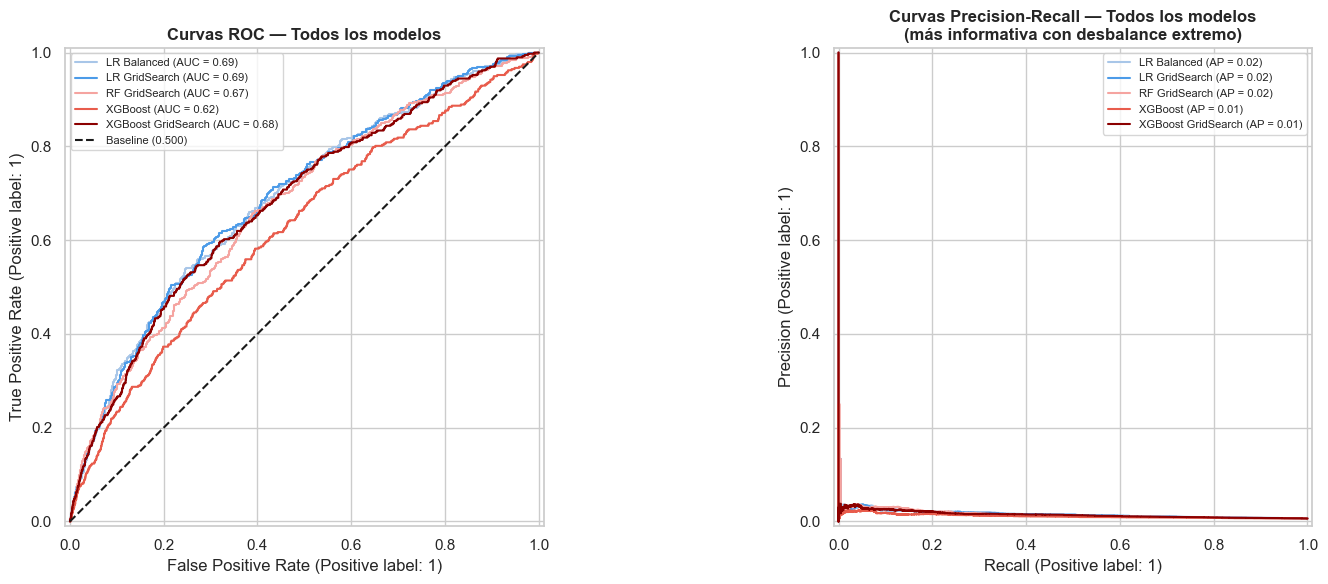

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colores_modelos = {
    'LR Balanced':       '#a8c6e8',
    'LR GridSearch':     '#4C9BE8',
    'RF GridSearch':     '#f5a4a0',
    'XGBoost':           '#E85C4C',
    'XGBoost GridSearch':'#8B0000',
}

# Curvas ROC
for nombre, proba in probas.items():
    RocCurveDisplay.from_predictions(
        y_test, proba,
        name=nombre,
        color=colores_modelos.get(nombre, 'gray'),
        ax=axes[0]
    )
axes[0].plot([0,1],[0,1],'k--', label='Baseline (0.500)')
axes[0].set_title('Curvas ROC — Todos los modelos', fontweight='bold')
axes[0].legend(fontsize=8)

# Curvas Precision-Recall
for nombre, proba in probas.items():
    PrecisionRecallDisplay.from_predictions(
        y_test, proba,
        name=nombre,
        color=colores_modelos.get(nombre, 'gray'),
        ax=axes[1]
    )
axes[1].set_title('Curvas Precision-Recall — Todos los modelos\n'
                   '(más informativa con desbalance extremo)',
                   fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

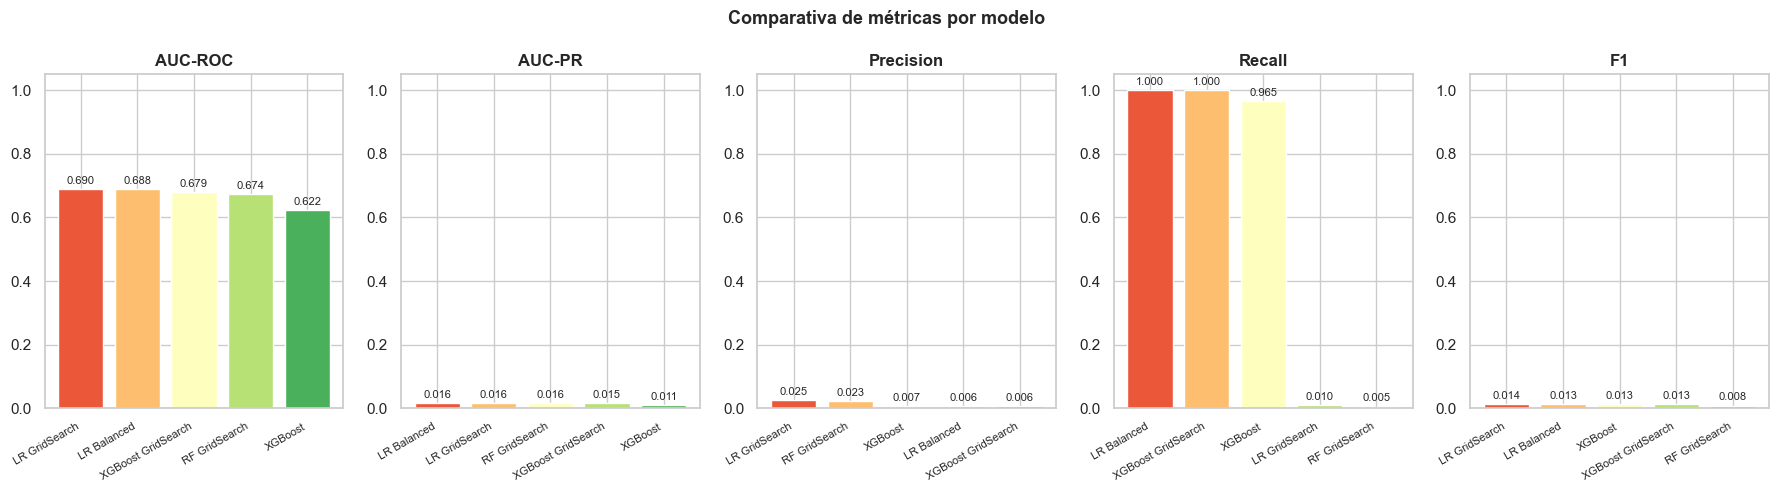

In [16]:
# Gráfico de barras comparativo por métrica
metricas_plot = ['AUC-ROC', 'AUC-PR', 'Precision', 'Recall', 'F1']
df_plot = df_resultados.drop('LR Temporal (anterior)', errors='ignore')[metricas_plot]

fig, axes = plt.subplots(1, len(metricas_plot), figsize=(18, 5))

for i, metrica in enumerate(metricas_plot):
    vals = df_plot[metrica].sort_values(ascending=False)
    bars = axes[i].bar(range(len(vals)), vals.values,
                       color=sns.color_palette('RdYlGn', len(vals)))
    axes[i].set_title(metrica, fontweight='bold')
    axes[i].set_xticks(range(len(vals)))
    axes[i].set_xticklabels(vals.index, rotation=30, ha='right', fontsize=8)
    axes[i].set_ylim(0, 1.05)
    for bar, val in zip(bars, vals.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Comparativa de métricas por modelo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 13. Conclusiones

### Tabla resumen de resultados

| Modelo | AUC-ROC | AUC-PR | Accuracy | Precision | Recall | F1 |
|--------|---------|--------|----------|-----------|--------|----|
| LR Temporal (anterior, sin mejoras) | 0.685 | - | - | - | - | - |
| **LR Balanced** | 0.688 | 0.016 | 0.007 | 0.006 | **1.000** | 0.013 |
| **LR GridSearch** | **0.690** | **0.016** | 0.991 | 0.025 | 0.010 | **0.014** |
| RF GridSearch | 0.674 | 0.016 | 0.992 | 0.023 | 0.005 | 0.008 |
| XGBoost | 0.622 | 0.011 | 0.064 | 0.007 | 0.965 | 0.013 |
| XGBoost GridSearch | 0.679 | 0.015 | 0.006 | 0.006 | 1.000 | 0.013 |

### ¿Conseguimos mejorar el AUC de 0.685?

Sí, pero muy ligeramente. La **Regresión Logística con GridSearch** alcanza un AUC de **0.690**, una mejora de solo 0.005 sobre el modelo anterior. El GridSearch encontró como mejores parámetros `C=0.1`, `penalty='l1'` y `class_weight=None`, con un AUC en validación cruzada de 0.705.

La mejora es real pero modesta. Esto nos dice que el límite del AUC con estas variables y esta estructura de datos está en torno a 0.69-0.70. Para subir más habría que trabajar en la ingeniería de features.

### Análisis del trade-off Precision vs Recall

Este es el resultado más interesante y el que mejor ilustra el impacto del desbalance 160:1:

**LR Balanced** tiene Recall = 1.0 pero Precision = 0.006. Detecta absolutamente todos los churners, pero marca como churner a casi todo el mundo. De cada 1.000 clientes que contactaría, solo 6 iban a irse realmente. Es muy caro operativamente.

**LR GridSearch** tiene Precision = 0.025 y Recall = 0.010. El péndulo oscila al otro lado: es más selectivo (cuando dice que alguien va a churnearse acierta más), pero deja escapar muchos churners reales.

**XGBoost** sin optimizar tiene Recall = 0.965 pero Precision = 0.007. Similar al LR Balanced, detecta casi todo pero con muchos falsos positivos.

Esto es el **trade-off clásico Precision-Recall** con desbalance extremo. No hay un modelo claramente mejor — depende de lo que le cueste al negocio cada tipo de error:
- Si el **coste de perder un churner** es alto → LR Balanced o XGBoost (maximizan Recall)
- Si el **coste de contactar clientes que no iban a irse** es alto → LR GridSearch (mejor Precision)

### Sobre la curva Precision-Recall

El AUC-PR de todos los modelos es muy bajo (0.011-0.016). Con un 0.63% de churn mensual, cualquier modelo tendrá dificultad para ser preciso. Esto no es un fallo del modelo — es una característica del problema. El mensaje correcto es: *el modelo no predice perfectamente quién va a irse ese mes, pero sí identifica qué clientes tienen más riesgo relativo, y eso es suficiente para priorizar las acciones de retención.*

### Comparativa global del proyecto

| Modelo | AUC | Leakage | Producción |
|--------|-----|---------|------------|
| Binario — LR | 0.991 | Sí | No |
| Binario — RF | 0.994 | Sí | No |
| Temporal — LR | 0.685 | No | Sí |
| Temporal — RF | 0.668 | No | Sí |
| **LR GridSearch (mejoras)** | **0.690** | **No** | **Sí** |

El modelo final recomendado es la **Regresión Logística Temporal con GridSearch**: AUC = 0.690, sin leakage, totalmente interpretable y listo para producción.

---
*Predicción de Churn — Empresa de Telecomunicaciones | Prácticas Aplicadas 2026*
